In [1]:
from collections import Counter

import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
from IPython.display import Markdown
from ipywidgets import HTML
from ipyleaflet import Map, Marker, MarkerCluster, Popup

In [2]:
fname = "PyCampAna 2026 (Responses) - Form Responses 1.csv"
df = pd.read_csv(fname)

coords_fname = "cities_coords.csv"
coords_df = pd.read_csv(coords_fname, index_col="Unnamed: 0")

In [3]:
def word_c(col_name, replacements={}, exclude=[], show_counter=False):
    col = df[col_name].fillna("").str.strip().str.lower()
    if replacements:
        for k,v in replacements.items():
            col = col.str.replace(k,v)
    show_counter and print(col.value_counts())
    words_count = Counter(map(str.strip, (col.str.cat(sep=",").split(","))))
    all_words = col.str.cat(sep=" ")
    stopwords = STOPWORDS.union(["de", "el", "del", "la", "en", "las", "que", "y", "muy", "un", "o"])
    wordcloud = WordCloud(width = 720, height = 720,
                background_color ='white',
                stopwords = stopwords.union(exclude),
                min_font_size = 10).generate(all_words)

    # plot the WordCloud image                      
    plt.figure(figsize = (8, 8), facecolor = None)
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.tight_layout(pad = 0)

    plt.show()

In [4]:
def add_coords(df, coords_df, replacements={}):
    df = df.copy()
    df["city"] = df["¿De dónde venís? (por lo menos ciudad + provincia)"].str.lower().str.strip().replace(replacements)
    df_full = df.merge(coords_df, on="city", how="left")
    return df_full

# ¿De dónde vinieron?

---

In [5]:
from geopy.geocoders import Nominatim

geolocator = Nominatim(timeout=10, user_agent="PyCampana Report 2026")

locations = {}

In [6]:
coords_df_extra = pd.DataFrame([
    {
    "city": key.strip().lower(),
    "lats": loc.latitude,
    "lngs": loc.longitude,
    "size": 1
    }
    for key, loc in locations.items()
    if loc is not None
])

coords_df_new = pd.concat([coords_df, coords_df_extra]).drop_duplicates(subset="city")
coords_df_new.reset_index(drop=True).to_csv(coords_fname)

---

In [7]:
replacements = {
    # CABA variants
    "caba": "CABA",
    "caba ": "CABA",
    "caba, buenos aires": "CABA",
    "ciudad autonoma de buenos aires": "CABA",
    "ciudad autónoma de buenos aires": "CABA",
    "cuidad de buenos aires": "CABA",  # typo
    "capital federal": "CABA",
    "ciudad de buenos aires": "CABA",

    # Buenos Aires province / GBA
    "lanús, buenos aires": "lanús, buenos aires",
    "vicente lópez, buenos aires": "vicente lópez, buenos aires",
    "vicente lópez, provincia de buenos aires": "vicente lópez, buenos aires",
    "villa adelina - buenos aires": "villa adelina, buenos aires",
    "monte grande": "monte grande, buenos aires",
    "hurlingham. capital del mundo": "hurlingham, buenos aires",

    # Ambiguous / messy
    "provincia bs as": "buenos aires",
    
    # Santa Fe
    "rafaela, santa fe": "rafaela, santa fe",
    "rafaela": "rafaela, santa fe",
    "santa fe, santa fe": "santa fe, santa fe",

    # Chaco
    "resistencia, chaco": "resistencia, chaco",

    # Córdoba
    "luyaba cba": "luyaba, córdoba",

    # Chubut
    "lago puelo, chubut": "lago puelo, chubut",
}



df_full = add_coords(df, coords_df, replacements=replacements)

In [19]:
m = Map(center=(-34.607568, -58.437089), zoom=4)

markers = []
for _, row in df_full.dropna(subset=["lats", "lngs"]).iterrows():
    marker = Marker(location=(row["lats"], row["lngs"]))

    message = HTML()
    message.value = row["¿De dónde venís? (por lo menos ciudad + provincia)"]
    marker.popup = message

    markers.append(marker)

marker_cluster = MarkerCluster(markers=markers, max_cluster_radius=20)

m.add(marker_cluster);
m

Map(center=[-34.607568, -58.437089], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title…

# Promedios

In [13]:
Markdown(f"""* ¿Cuántos kilómetros hiciste para llegar?	**{df["¿Cuántos kilómetros hiciste para llegar?"].mean().round(-1):.2f}** (530.0)
* ¿Cuántas veces te bañaste?	**{df["¿Cuántas veces te bañaste?"].median():.2f}** (4.0)
* ¿A cuántos PyCamp fuiste? (contando el actual)?	**{df["¿A cuántos PyCamp fuiste? (contando el actual)?"].median():.2f}** (4.0)
* ¿En cuántos proyectos participaste en este PyCamp?	**{df["¿En cuántos proyectos participaste en este PyCamp?"].median():.2f}** (2.0)
* ¿Qué nota le pondrías a la comida?	**{df["¿Qué nota le pondrías a la comida?"].mean():.2f}** (8.21)
* ¿Qué nota le pondrías a los dormitorios?	**{df["¿Qué nota le pondrías a los dormitorios?"].mean():.2f}** (5.95)
* ¿Qué nota le pondrías a Internet?	**{df["¿Qué nota le pondrías a Internet?"].mean():.2f}** (7.95)
* ¿Qué nota le pondrías al lugar?	**{df["¿Qué nota le pondrías al lugar?"].mean():.2f}** (8.31)
* Tu edad	**{df["Tu edad"].mean():.2f}** (34.92)
* ¿Tenés hijes?	**{(df["¿Tenés hijes?"].value_counts(normalize=True).loc[0] * 100).round(1)} %** no tiene, el resto tiene **{df.loc[(df["¿Tenés hijes?"] != 0) & (df["¿Tenés hijes?"].notna()), "¿Tenés hijes?"].mean().round(1)}** hijes de media (1.9)
""")

* ¿Cuántos kilómetros hiciste para llegar?	**1490.00** (530.0)
* ¿Cuántas veces te bañaste?	**3.00** (4.0)
* ¿A cuántos PyCamp fuiste? (contando el actual)?	**5.00** (4.0)
* ¿En cuántos proyectos participaste en este PyCamp?	**2.00** (2.0)
* ¿Qué nota le pondrías a la comida?	**8.38** (8.21)
* ¿Qué nota le pondrías a los dormitorios?	**8.08** (5.95)
* ¿Qué nota le pondrías a Internet?	**4.65** (7.95)
* ¿Qué nota le pondrías al lugar?	**9.04** (8.31)
* Tu edad	**37.15** (34.92)
* ¿Tenés hijes?	**73.1 %** no tiene, el resto tiene **1.7** hijes de media (1.9)


# Dónde debería ser el próximo PyCamp

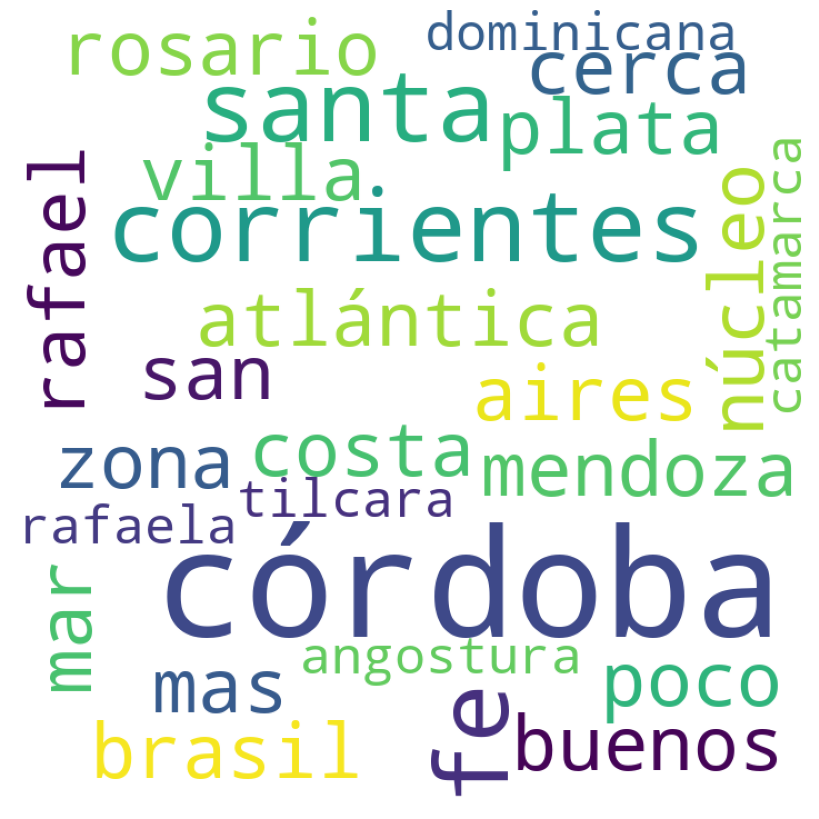

In [14]:
word_c(
    '¿Dónde te gustaría que se haga un PyCamp?', 
   replacements={'cordoba': "córdoba", 'jesús mario': "jesus maria", 
    "vla": "villa la angostura", "langosrura": "villa la angostura",}
)

# Nivel de manejo de Python de los PyCampistas

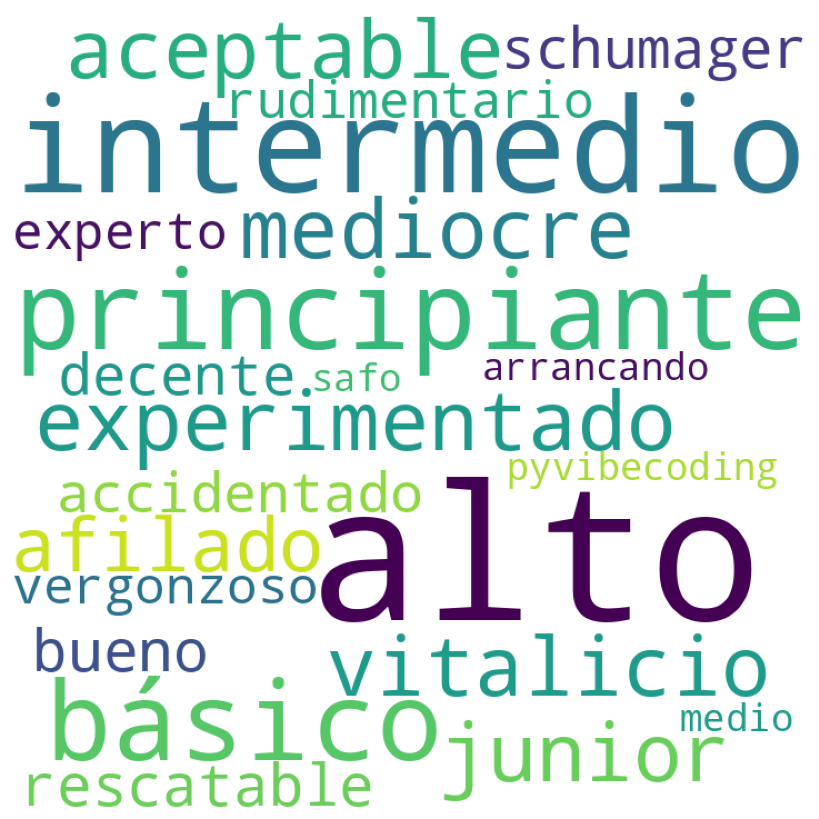

In [15]:
word_c(
    '¿Cómo describirías tu nivel de manejo de Python?', 
    replacements={"basico":"básico", "avanzaso":"avanzado"}, 
    exclude=["si", "sin", "al", "de", "mi", "su"]
)

# Feedback

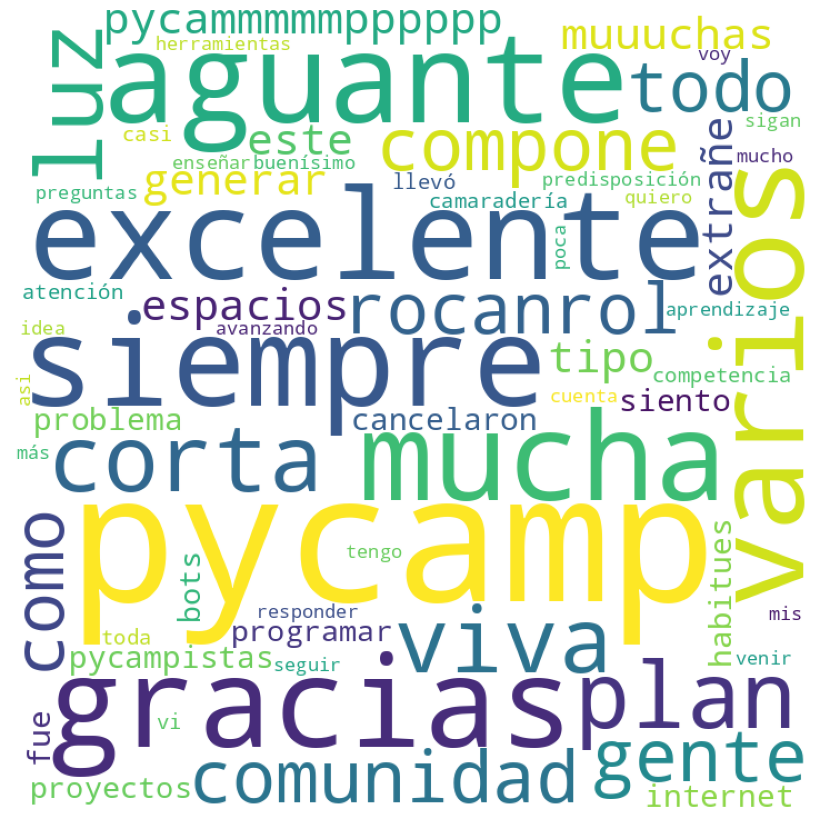

In [16]:
word_c(
    "¿Querés dejar algún otro feedback?",
    replacements={"ek":"el"},
    exclude=["estuvo", "hacen", "esta", "d", "mi", "su", "estoy", "son", "así", "otra", "lo", "pre", "mas", "se", "es", "les", "por", "si", "los", "las", "para", "ya", "con"]
)

# Místico

# ¿Cuánto se bañan por cada signo?

In [24]:
Markdown(
    "\n".join(
        f"* {signo} **{freq}**"
        for signo, freq
        in df.groupby("¿Cuál es tu signo del zodíaco?")["¿Cuántas veces te bañaste?"].median().sort_values(ascending=False).items()
    )
)

* Aries **4.0**
* Virgo **4.0**
* Piscis **3.5**
* Leo **3.5**
* Acuario **3.0**
* Cáncer **3.0**
* Géminis **3.0**
* Escorpión **3.0**
* Tauro **3.0**
* Libra **2.5**

In [29]:
from IPython.display import Markdown

def funny_insights(df):
    insights = []

    # 1. Signo zodiacal
    zodiac = df["¿Cuál es tu signo del zodíaco?"].dropna().str.lower()
    vc = zodiac.value_counts()
    if len(vc) > 1:
        top, bottom = vc.idxmax(), vc.idxmin()
        top_pct = vc.max() / vc.sum() * 100
        bottom_pct = vc.min() / vc.sum() * 100
        insights.append(
            f"- El signo con más representación es **{top}** ({top_pct:.0f}%) mientras que el menos es **{bottom}** ({bottom_pct:.0f}%)."
        )

    # 2. Horóscopo chino
    chinese = df["¿Qué animal del horóscopo chino sos?"].dropna().str.lower()
    vc = chinese.value_counts()
    if len(vc) > 1:
        insights.append(
            f"- Predomina **{vc.idxmax()}** ({(vc.max()/vc.sum()*100):.0f}%), mientras que **{vc.idxmin()}** apenas aparece."
        )

    # 3. Higiene por signo (mínimo)
    baths_by_sign = df.groupby("¿Cuál es tu signo del zodíaco?")["¿Cuántas veces te bañaste?"].mean()
    baths_by_sign = baths_by_sign.dropna()
    if len(baths_by_sign) > 1:
        insights.append(
            f"- El signo que menos se bañó en promedio es **{baths_by_sign.idxmin()}** ({baths_by_sign.min():.1f})."
        )

    # 4. Higiene por experiencia PyCamp
    df_valid = df.dropna(subset=[
        "¿A cuántos PyCamp fuiste? (contando el actual)?",
        "¿Cuántas veces te bañaste?"
    ])

    if not df_valid.empty:
        many = df_valid[df_valid["¿A cuántos PyCamp fuiste? (contando el actual)?"] >= 3]
        few = df_valid[df_valid["¿A cuántos PyCamp fuiste? (contando el actual)?"] < 3]

        if not many.empty and not few.empty:
            insights.append(
                f"- Quienes vinieron a ≥3 PyCamps se bañaron **{many['¿Cuántas veces te bañaste?'].mean():.1f}** veces en promedio vs **{few['¿Cuántas veces te bañaste?'].mean():.1f}** los nuevos."
            )

    # 5. Python vs Internet
    g = df.groupby("¿Programaste Python durante el PyCamp?")["¿Qué nota le pondrías a Internet?"].mean()
    g = g.dropna()
    if len(g) == 2:
        insights.append(
            f"- Quienes programaron durante el pycamp calificaron Internet con **{g.get('Si', g.max()):.1f}** vs **{g.get('No', g.min()):.1f}** quienes no."
        )

    # 6. Transporte
    transport = df["¿En qué llegaste?"].dropna().str.lower()
    vc = transport.value_counts()
    if len(vc) > 0:
        insights.append(
            f"- El medio más usado fue **{vc.idxmax()}** ({(vc.max()/vc.sum()*100):.0f}%)."
        )

    return Markdown("\n".join(insights))

In [30]:
funny_insights(df)

- El signo con más representación es **leo** (15%) mientras que el menos es **acuario** (4%).
- Predomina **rata** (16%), mientras que **cerdo** apenas aparece.
- El signo que menos se bañó en promedio es **Libra** (2.5).
- Quienes vinieron a ≥3 PyCamps se bañaron **3.2** veces en promedio vs **3.7** los nuevos.
- Quienes programaron durante el pycamp calificaron Internet con **4.6** vs **4.8** quienes no.
- El medio más usado fue **avión** (73%).